In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import perceptron

In [2]:
# column information in 'fish3.txt'
fish3 = pd.read_csv("fish3.csv")
fish3

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes
...,...,...,...,...,...,...,...,...,...,...,...
8337,22.0,8.160515,0.742393,0.394320,0.307719,0.332283,0.793826,0.600208,0.105301,3.951881,Perciformes
8338,50.0,5.241134,0.600061,0.377792,0.293883,0.301585,0.617588,0.481677,0.133632,3.565657,Perciformes
8339,4.0,3.159920,0.453558,0.560501,0.533168,0.175106,0.470270,0.324433,0.187150,2.395070,Cyprinodontiformes
8340,140.0,4.165031,0.545773,0.115646,0.471200,0.483810,0.498305,0.223729,0.163095,2.091741,Siluriformes


In [3]:
# dataset input parameters

order1_name = "Tetraodontiformes"
order2_name = "Anguilliformes"
x1_name = "VEp"
x2_name = "PFs" 

# NOTE: the model doesn't always converge with these features. Try CPt instead of PFs for a more consistent result!

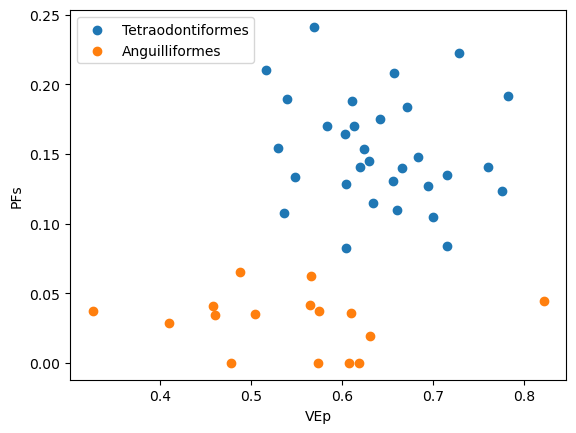

In [4]:
# plot selected classes and features

order = np.array(fish3['Order'])
order1 = np.where(order == order1_name)
order2 = np.where(order == order2_name)
x1 = np.array(fish3[x1_name])
x2 = np.array(fish3[x2_name])

plt.scatter(x1[order1], x2[order1], label=order1_name)
plt.scatter(x1[order2], x2[order2], label=order2_name)
plt.xlabel(x1_name)
plt.ylabel(x2_name)
plt.legend()
plt.show()

Trained model error: 0


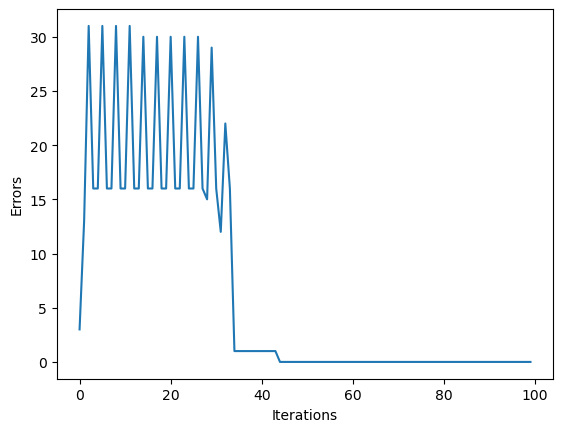

In [10]:
# format data for training
idcs = np.concatenate((order1, order2), 1)[0]
np.random.shuffle(idcs)
X = np.stack((x1[idcs], x2[idcs])).transpose()
Y = np.where(order[idcs] == order1_name, 0.0, 1.0)

# train perceptron
lr = 0.0001
n = 100
W, b, errors = perceptron.train(lr, n, X, Y)
print(f"Trained model error: {errors[-1]}")

# plot training progress
plt.plot([i for i in range(n)], errors)
plt.xlabel("Iterations")
plt.ylabel("Errors")
plt.show()

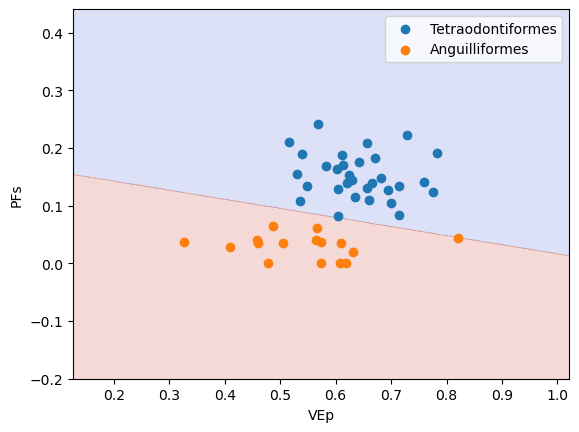

In [11]:
# plot decision regions

x1_min, x1_max = X[:, 0].min()-0.2, X[:, 0].max()+0.2
x2_min, x2_max = X[:, 1].min()-0.2, X[:, 1].max()+0.2
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.001), np.arange(x2_min, x2_max, 0.001))
lab = perceptron.predict(np.array([xx1.ravel(), xx2.ravel()]).T, W, b)
lab = lab.reshape(xx1.shape)
plt.contourf(xx1, xx2, lab, alpha=0.2, cmap='coolwarm')
plt.xlim(xx1.min(), xx1.max())
plt.ylim(xx2.min(), xx2.max())

plt.scatter(x1[order1], x2[order1], label=order1_name)
plt.scatter(x1[order2], x2[order2], label=order2_name)
plt.xlabel(x1_name)
plt.ylabel(x2_name)
plt.legend()
plt.show()